In [1]:
!wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar

--2026-04-06 05:43:15--  https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 1045106394 (997M) [application/x-rar-compressed]
Saving to: ‘UCF11_updated_mpg.rar’

UCF11_updated_mpg.r 100%[===================>] 996.69M  12.8MB/s    in 88s     

2026-04-06 05:44:45 (11.3 MB/s) - ‘UCF11_updated_mpg.rar’ saved [1045106394/1045106394]



In [2]:
!apt-get update
!apt-get install -y unar

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,482 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,844 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu ja

In [3]:
!unar UCF11_updated_mpg.rar

UCF11_updated_mpg.rar: RAR
  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_01.mpg  (239616 B)... OK.
  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_02.mpg  (288768 B)... OK.
  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_03.mpg  (286720 B)... OK.
  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_04.mpg  (231424 B)... OK.
  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_05.mpg  (339968 B)... OK.
  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_06.mpg  (380928 B)... OK.
  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_07.mpg  (428032 B)... OK.
  UCF11_updated_mpg/basketball/v_shooting_02/v_shooting_02_01.mpg  (305152 B)... OK.
  UCF11_updated_mpg/basketball/v_shooting_02/v_shooting_02_02.mpg  (196608 B)... OK.
  UCF11_updated_mpg/basketball/v_shooting_02/v_shooting_02_03.mpg  (370688 B)... OK.
  UCF11_updated_mpg/basketball/v_shooting_02/v_shooting_02_04.mpg  (294912 B)... OK.
  UCF11_updated_mpg/basketball/v_shoot

In [5]:

# Copyright (c) Microsoft. All rights reserved.
# Licensed under the MIT license. See LICENSE.md file in the project root for full license information.
#

import os
import sys
import argparse
import csv
import numpy as np

import imageio

from tqdm import tqdm

import pandas as pd
from sklearn.model_selection import train_test_split


def load_groups(input_folder):
    '''
    Load the list of sub-folders into a python list with their
    corresponding label.
    '''
    groups         = []
    label_folders  = os.listdir(input_folder)
    index          = 0
    for label_folder in sorted(label_folders):
        label_folder_path = os.path.join(input_folder, label_folder)
        if os.path.isdir(label_folder_path):
            group_folders = os.listdir(label_folder_path)
            for group_folder in group_folders:
                if group_folder != 'Annotation':
                    groups.append([os.path.join(label_folder_path, group_folder), index])
            index += 1

    return groups

def split_data(groups, file_ext):
    '''
    Split the data at random for train, eval and test set.
    '''
    group_count = len(groups)
    indices = np.arange(group_count)

    np.random.seed(0) # Make it deterministic.
    np.random.shuffle(indices)

    # 80% training and 20% test.
    train_count = int(0.8 * group_count)
    test_count  = group_count - train_count

    train = []
    test  = []

    for i in tqdm(range(train_count)):
        group = groups[indices[i]]
        video_files = os.listdir(group[0])
        for video_file in video_files:
            video_file_path = os.path.join(group[0], video_file)
            if os.path.isfile(video_file_path):
                video_file_path = os.path.abspath(video_file_path)
                ext = os.path.splitext(video_file_path)[1]
                if (ext == file_ext):
                    # make sure we have enough frames and the file isn't corrupt
                    video_reader = imageio.get_reader(video_file_path, 'ffmpeg')
                    if len(video_reader) >= 16:
                        train.append([video_file_path, group[1]])

    for i in tqdm(range(train_count, train_count + test_count)):
        group = groups[indices[i]]
        video_files = os.listdir(group[0])
        for video_file in video_files:
            video_file_path = os.path.join(group[0], video_file)
            if os.path.isfile(video_file_path):
                video_file_path = os.path.abspath(video_file_path)
                ext = os.path.splitext(video_file_path)[1]
                if (ext == file_ext):
                    # make sure we have enough frames and the file isn't corrupt
                    video_reader = imageio.get_reader(video_file_path, 'ffmpeg')
                    if len(video_reader) >= 16:
                        test.append([video_file_path, group[1]])

    return train, test

def write_to_csv(items, file_path):
    '''
    Write file path and its target pair in a CSV file format.
    '''
    if sys.version_info[0] < 3:
        with open(file_path, 'wb') as csv_file:
            writer = csv.writer(csv_file, delimiter=',')
            for item in items:
                writer.writerow(item)
    else:
        with open(file_path, 'w', newline='') as csv_file:
            writer = csv.writer(csv_file, delimiter=',')
            for item in items:
                writer.writerow(item)


def split_train_test_val(input_folder, output_folder):
    '''
    Main entry point, it iterates through all the video files in a folder or through all
    sub-folders into a list with their corresponding target label. It then split the data
    into training set and test set.
    :param input_folder: input folder contains all the video contents.
    :param output_folder: where to store the result.
    '''
    groups = load_groups(input_folder)
    train, test = split_data(groups, '.mpg')

    write_to_csv(train, os.path.join(output_folder, 'train_map.csv'))
    write_to_csv(test, os.path.join(output_folder, 'test_map.csv'))

    # Load the CSV file
    df = pd.read_csv(os.path.join(output_folder, 'train_map.csv'))

    # Split the data into 90% training and 10% validation
    train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)

    # Write the training set to a new CSV file
    train_df.to_csv(os.path.join(output_folder, 'train_map.csv'), index=False)

    # Write the validation set to a new CSV file
    val_df.to_csv(os.path.join(output_folder, 'val_map.csv'), index=False)

    test_df = pd.read_csv(os.path.join(output_folder, 'test_map.csv'))

    print(f"Training set: {len(train_df)} samples")
    print(f"Validation set: {len(val_df)} samples")
    print(f"Test set: {len(test_df)} samples")

input_folder = '/content/UCF11_updated_mpg'
output_folder = '/content/output_UCF11'

split_train_test_val(input_folder, output_folder)

100%|██████████| 55/55 [00:11<00:00,  4.72it/s]

Training set: 1170 samples
Validation set: 131 samples
Test set: 297 samples


In [6]:
import pandas as pd
from IPython.display import Video
import cv2
import torch

def ucf_dataloader(csv_path, fps = 16, frame_size = (64,64)):
    df = pd.read_csv(csv_path)
    df.columns = ["filepath", "label"]
    data = []
    for idx, row in df.iterrows():
        vid_pth = row['filepath']
        vid_label = row['label']
        # vid = Video(vid_pth)

        frame_loop = imageio.get_reader(vid_pth, 'ffmpeg')
        frames = []

        for i , frame in enumerate(frame_loop):
            grayimage = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
            imageresized = cv2.resize(grayimage, frame_size)
            imagenormalized = imageresized / 255.0
            imagenormalized = np.expand_dims(imagenormalized, axis=0) #shape to (1,h,w)
            frames.append(imagenormalized)
            if len(frames) == fps:
                break
        while len(frames) < fps:
            frames.append(frames[-1])
        video_tensor = torch.tensor(np.array(frames), dtype=torch.float32)

        data.append((video_tensor, vid_label))
    return data

In [7]:
from torchvision import models
import torch.nn as nn
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(pretrained = True)
        #modification
        resnet.conv1 = nn.Conv2d(
            1, # we only change this (input channels)
            resnet.conv1.out_channels,
            kernel_size=resnet.conv1.kernel_size,
            stride=resnet.conv1.stride,
            padding=resnet.conv1.padding,
            bias=False
        )
        for params in resnet.parameters():
            params.requires_grad = False

        self.resnet = nn.Sequential(*list(resnet.children())[:-1])  #out is (B, 512,1, 1)
        self.lstm = nn.LSTM(input_size=512, hidden_size=256, num_layers=1, batch_first=True)
        self.classifier = nn.Linear(256, 11)

    def forward(self, x): #x has shape (b, fps, 1, 64, 64)
        batch_size, num_frames, C, H, W = x.shape
        cnn_feats = []
        for t in range(num_frames):
            frame = x[:, t, :, :, :]
            out1 = self.resnet(frame)
            out1 = out1.view(batch_size, -1)
            cnn_feats.append(out1)

        features = torch.stack(cnn_feats, dim = 1) #(b, frames, 512)
        lstm_out, (h_n, c_n) = self.lstm(features)
        last_hidden = h_n[-1]  # (batch, 256)

        logits = self.classifier(last_hidden)
        return logits

In [8]:
from torch.utils.data import Dataset, DataLoader

train_dataset = ucf_dataloader("/content/output_UCF11/train_map.csv")
test_dataset = ucf_dataloader("/content/output_UCF11/test_map.csv")
val_dataset = ucf_dataloader("/content/output_UCF11/val_map.csv")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True)



model = Model()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(list(model.lstm.parameters()) + list(model.classifier.parameters()), lr=1e-3)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 131MB/s]


In [9]:
def evaluate(model, loader, criterion, device='cuda'):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # no gradient computation
        for videos, labels in loader:
            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * videos.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [10]:
import matplotlib.pyplot as plt
from tqdm import tqdm

def training_loop(model, train_loader, test_loader, val_loader, optimizer, criterion, device='cuda', epochs=5):
    model.to(device)

    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    for epoch in tqdm(range(epochs)):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for videos, labels in train_loader:
            videos = videos.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(videos)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * videos.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)


        epoch_loss = running_loss / total
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


    epochs_range = range(1, epochs + 1)
    plt.figure(figsize=(12,5))

    # loss
    plt.subplot(1,2,1)
    plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs_range, val_losses, label='Val Loss', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # acc
    plt.subplot(1,2,2)
    plt.plot(epochs_range, train_accs, label='Train Acc', marker='o')
    plt.plot(epochs_range, val_accs, label='Val Acc', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.show()

 20%|██        | 1/5 [00:06<00:27,  6.76s/it]

Epoch 1/5 - Train Loss: 2.3043, Train Acc: 0.1932, Val Loss: 2.3356, Val Acc: 0.1450


 40%|████      | 2/5 [00:12<00:17,  5.90s/it]

Epoch 2/5 - Train Loss: 2.0523, Train Acc: 0.3111, Val Loss: 2.2047, Val Acc: 0.2290


 60%|██████    | 3/5 [00:17<00:11,  5.68s/it]

Epoch 3/5 - Train Loss: 1.9327, Train Acc: 0.3504, Val Loss: 2.2125, Val Acc: 0.2137


 80%|████████  | 4/5 [00:22<00:05,  5.48s/it]

Epoch 4/5 - Train Loss: 1.8099, Train Acc: 0.4094, Val Loss: 2.3028, Val Acc: 0.2137


100%|██████████| 5/5 [00:28<00:00,  5.67s/it]

Epoch 5/5 - Train Loss: 1.6753, Train Acc: 0.4641, Val Loss: 2.3382, Val Acc: 0.2290


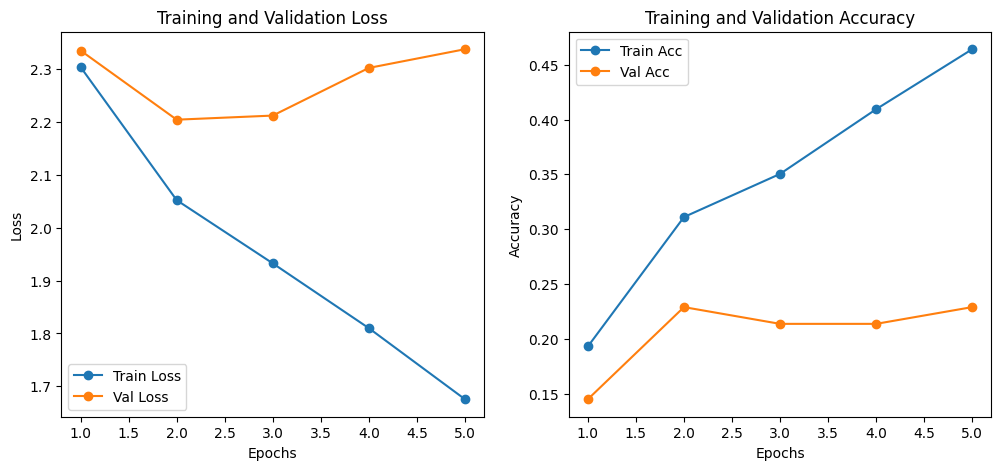

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
training_loop(model, train_loader, test_loader, val_loader, optimizer, criterion, device=device, epochs=5)